In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import scanpy as sc
import anndata as ad
import skimage as skimage

In [24]:
PROJECT_ROOT = Path.cwd().resolve().parent
input_file = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "bbn963sq6_filtered_feature_bc_matrix.h5"
)

if not input_file.exists():
    raise FileNotFoundError(f"Input file not found: {input_file}")

output_dir = PROJECT_ROOT / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

UMAP_STYLE = {
    "legend_loc": "on data",
    "legend_fontsize": 9,
    "legend_fontweight": "semibold",
    "legend_fontoutline": 2,
    "size": 20,
    "alpha": 0.85,
    "marker": "o",
    "add_outline": True,
    "outline_width": (0.2, 0.03),
    "palette": "Set1",
    "ncols": 2,
    "wspace": 0.3,
}

In [25]:
adata = sc.read_h5ad(output_dir / "bbn963sq6_processed_unlabeled.h5ad")

adata_leukocytes = adata[adata.obs["leukocyte_cluster_call"] == "Leukocyte", :].copy()

In [26]:
adata

AnnData object with n_obs × n_vars = 4837 × 22886
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leukocyte_score', 'leukocyte_reference_bool', 'leukocyte_reference', 'leiden', 'leukocyte_cluster_call'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden', 'leiden_colors', 'leukocyte_cluster_call_colors', 'leukocyte_reference_colors', 'log1p', 'ne

In [27]:
adata_leukocytes

AnnData object with n_obs × n_vars = 2839 × 22886
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leukocyte_score', 'leukocyte_reference_bool', 'leukocyte_reference', 'leiden', 'leukocyte_cluster_call'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden', 'leiden_colors', 'leukocyte_cluster_call_colors', 'leukocyte_reference_colors', 'log1p', 'ne

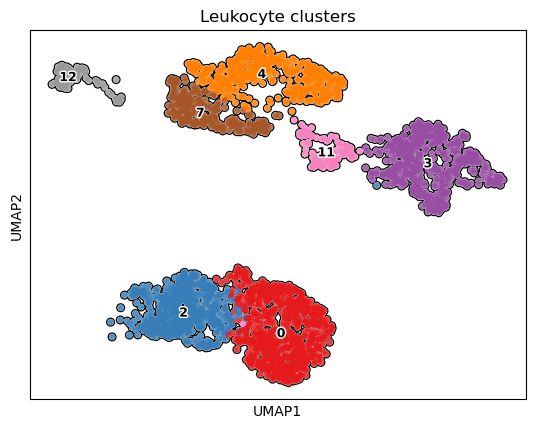

In [6]:
sc.pl.umap(adata_leukocytes, 
           color="leiden",
           **UMAP_STYLE,
           title="Leukocyte clusters")

In [7]:
# keys: cell types or populations, values: lists of marker genes

broad_cell_type_markers = {
    "Tumor_Urothelial": ["Epcam", "Krt8", "Krt18", "Krt19", "Upk1a", "Upk2", "Gata3", "Foxa1"],
    "T_Cells": ["Cd3d", "Cd3e", "Cd3g", "Trac", "Lck"],
    "B_Cells": ["Cd79a", "Cd79b", "Ms4a1", "Cd74", "Cd37"],
    "Macrophages": ["C1qa", "C1qb", "C1qc", "Csf1r", "Adgre1", "Fcgr1", "Mertk"],
    "Monocytes": ["Ly6c2", "Ccr2", "Plac8", "Lst1", "Lyz2"],
    "Neutrophils": ["Ly6g", "Csf3r", "Retnlg", "S100a8", "S100a9"],
    "Endothelial": ["Pecam1", "Cdh5", "Kdr", "Emcn"],
    "Fibroblasts": ["Col1a1", "Col1a2", "Dcn", "Pdgfra"],
    "NK_Cells": ["Ncr1", "Klrb1c", "Nkg7", "Prf1", "Gzmb"]
}

immune_cell_markers = {
    "Neutrophils": [
        "Ly6g", "Csf3r", "Retnlg", "Ngp",
        "Camp", "S100a8", "S100a9", "Mmp8"
],

    "Macrophages": [
        "C1qa", "C1qb", "C1qc", "Mertk",
        "Fcgr1", "Adgre1", "Apoe", "Ms4a7",
        "Csf1r", "Cd68"
    ],

    "Monocytes": [
        "Ly6c2", "Ccr2", "Plac8", "Sell",
        "S100a8", "S100a9", "Chil3", "Fn1"
    ],

    "B_Cells": [
        "Cd79a", "Cd79b", "Ms4a1",
        "Cd22", "Bank1", "Pax5", "Ebf1"
    ],

    "Pan_T_Cells": [
        "Cd3d", "Cd3e", "Cd3g",
        "Trac", "Lck", "Lat"
    ],

    "CD4_T_Cells": [
        "Cd3d", "Cd3e", "Trac",
        "Cd4", "Il7r", "Ccr7",
        "Tcf7", "Lef1", "Mal"
    ],

    "CD8_T_Cells": [
        "Cd3d", "Cd3e", "Trac",
        "Cd8a", "Cd8b1",
        "Ccl5", "Gzmk"
    ],

    "NK_Cells": [
        "Ncr1", "Klrk1", "Klrb1c",
        "Nkg7", "Prf1", "Gzmb", "Tyrobp"
    ]
}

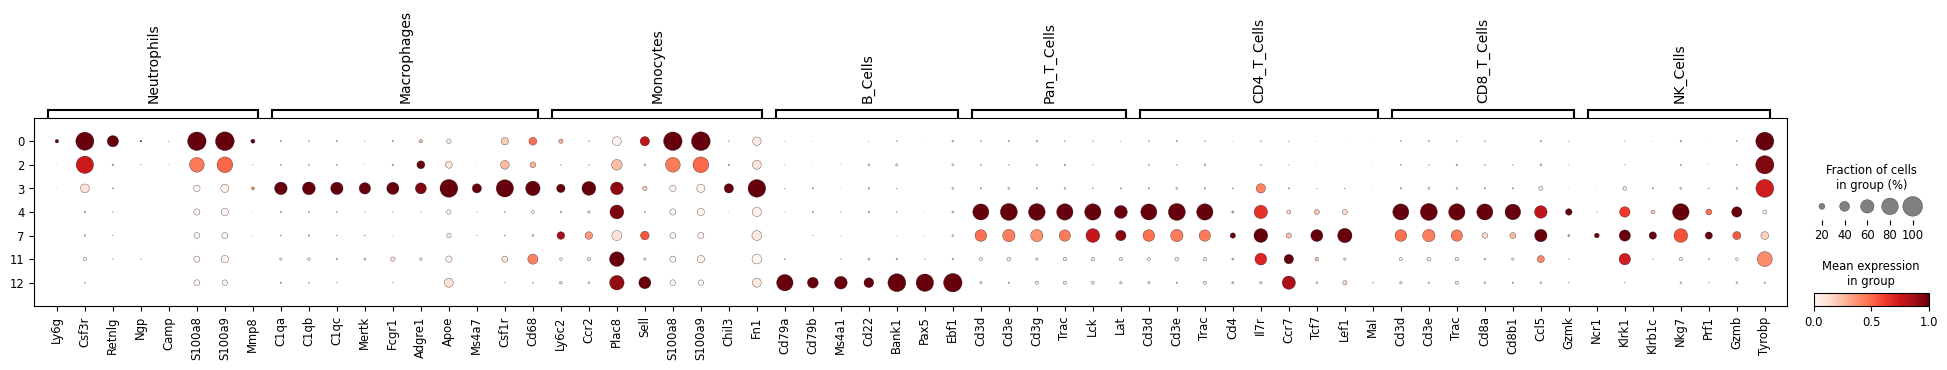

categories: 0, 2, 3, etc.
var_group_labels: Neutrophils, Macrophages, Monocytes, etc.


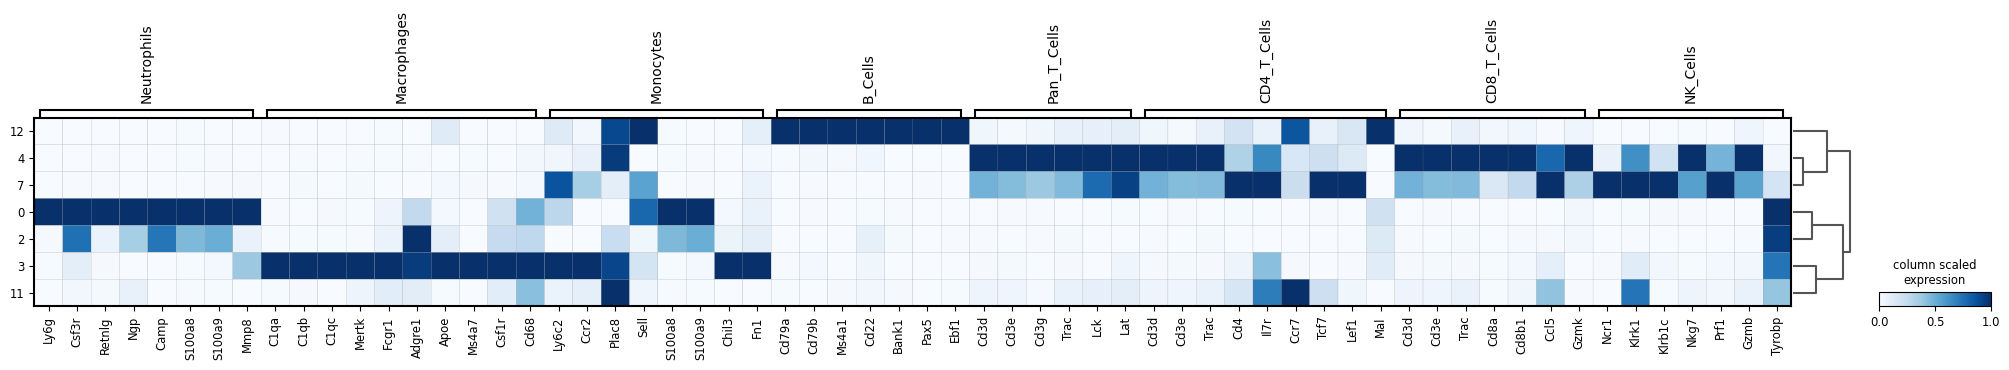

In [8]:
sc.pl.dotplot(adata_leukocytes, immune_cell_markers, groupby="leiden", standard_scale="var")
sc.pl.matrixplot(
    adata_leukocytes,
    immune_cell_markers,
    "leiden",
    dendrogram=True,
    cmap="Blues",
    standard_scale="var",
    colorbar_title="column scaled\nexpression",
)

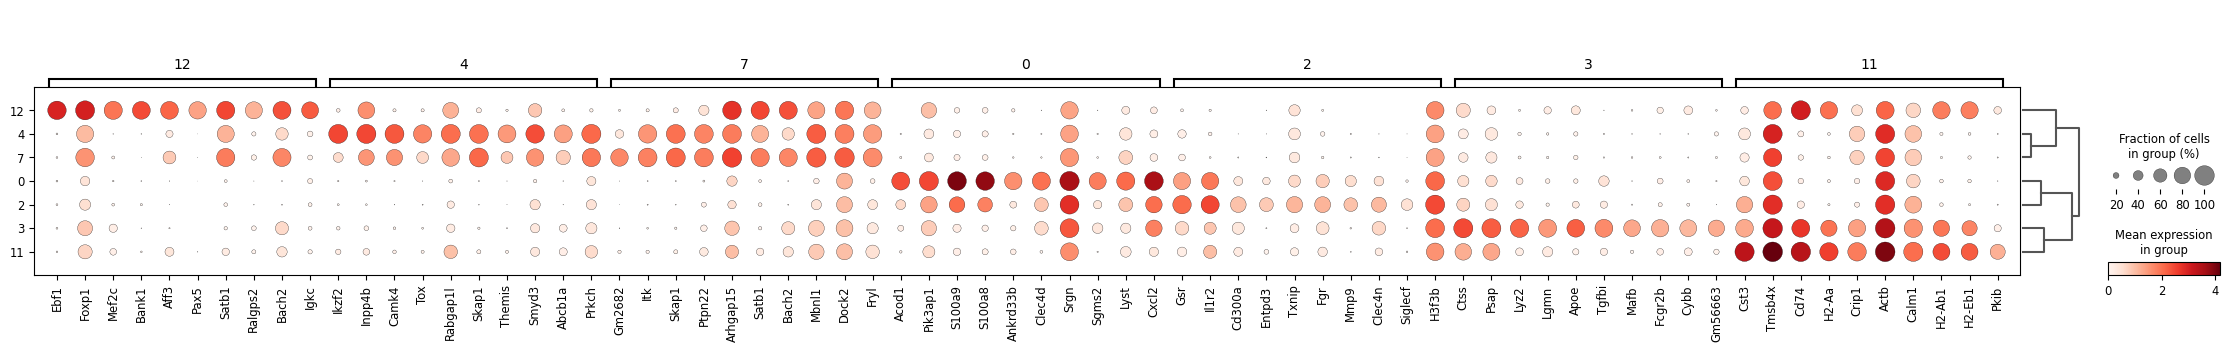

In [9]:
sc.tl.rank_genes_groups(
    adata_leukocytes,
    groupby="leiden",
    method="wilcoxon",
    use_raw=False,
)

sc.pl.rank_genes_groups_dotplot(
    adata_leukocytes,
    n_genes=10,
    groupby="leiden",
    standard_scale=None,
)

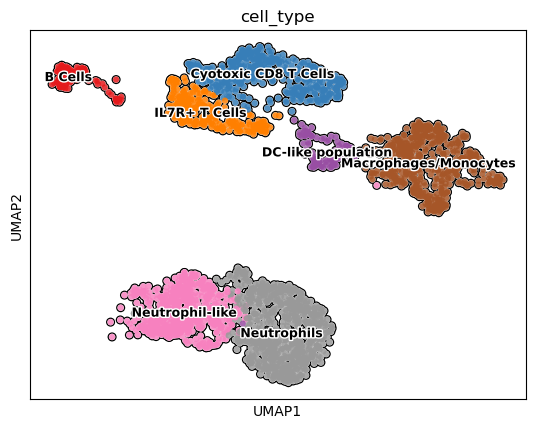

In [10]:
cluster_labels = {
    "0": "Neutrophils", 
    "2": "Neutrophil-like", 
    "3": "Macrophages/Monocytes", 
    "4": "Cyotoxic CD8 T Cells",
    "7": "IL7R+ T Cells",
    "11": "DC-like population",
    "12": "B Cells"
}

adata_leukocytes.obs["cell_type"] = (
    adata_leukocytes.obs["leiden"]
    .astype(str)
    .map(cluster_labels)
    .fillna("Unassigned")
    .astype("category")
)

sc.pl.umap(
    adata_leukocytes,
    color=["cell_type"],
    **UMAP_STYLE
)

In [11]:
n_macrophages = (
    adata_leukocytes.obs["cell_type"] == "Macrophages/Monocyte"
).sum()

n_leukocytes = adata_leukocytes.n_obs

macrophage_percentage = 100 * n_macrophages / n_leukocytes

print(f"Macrophages: {n_macrophages}")
print(f"Total leukocytes: {n_leukocytes}")
print(f"Macrophage percentage: {macrophage_percentage:.2f}%")

Macrophages: 0
Total leukocytes: 2839
Macrophage percentage: 0.00%


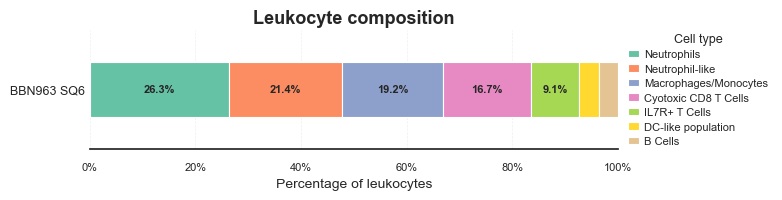

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = (
    adata_leukocytes.obs["cell_type"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
    .to_frame()
    .T
)

plot_data.index = ["BBN963 SQ6"]

sns.set_theme(style="white", context="notebook")

colors = sns.color_palette("Set2", n_colors=plot_data.shape[1])

fig, ax = plt.subplots(figsize=(8, 2.2))

plot_data.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=colors,
    width=0.42,
    edgecolor="white",
    linewidth=0.8,
)

for container in ax.containers:
    labels = [
        f"{bar.get_width():.1f}%"
        if bar.get_width() >= 4
        else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8,
        fontweight="semibold",
    )

ax.set_title(
    "Leukocyte composition",
    fontsize=13,
    fontweight="bold",
    pad=5,
)

ax.set_xlabel("Percentage of leukocytes", fontsize=10, labelpad=4)
ax.set_ylabel("")
ax.set_xlim(0, 100)

ax.set_xticks(range(0, 101, 20))
ax.set_xticklabels(
    [f"{x}%" for x in range(0, 101, 20)],
    fontsize=8,
)

ax.tick_params(axis="y", labelsize=9, length=0)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.3)

ax.legend(
    title="Cell type",
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
    frameon=False,
    fontsize=8,
    title_fontsize=9,
    handlelength=1,
    handletextpad=0.5,
    labelspacing=0.4,
    borderaxespad=0,
)

fig.subplots_adjust(
    left=0.12,
    right=0.78,
    top=0.82,
    bottom=0.28,
)

plt.savefig(
    output_dir / "BBN963__leukocyte_composition.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.05,
)

plt.show()

In [7]:
for ct, markers in cluster_4_markers.items():
    markers_found = []
    for marker in markers:
        if marker in adata.var.index:
            markers_found.append(marker)
    cluster_4_markers[ct] = markers_found

cluster_4_names = list(cluster_4_markers.keys())
for ct in cluster_4_names:
    print(f"{ct.upper()}:")  # print cell subtype name
    sc.pl.umap(
        adata,
        color=cluster_4_markers[ct],
        vmin=0,
        vmax="p99",  # set vmax to the 99th percentile of the gene count instead of the maximum, to prevent outliers from making expression in other cells invisible. Note that this can cause problems for extremely lowly expressed genes.
        sort_order=False,  # do not plot highest expression on top, to not get a biased view of the mean expression among cells
        frameon=False,
        cmap="Reds",  # or choose another color map e.g. from here: https://matplotlib.org/stable/tutorials/colors/colormaps.html
    )
    print("\n\n\n")  # print white space for legibility

NameError: name 'cluster_4_markers' is not defined

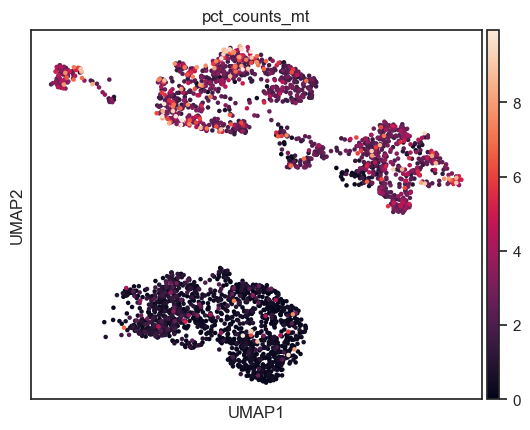

In [22]:
sc.pl.umap(adata_leukocytes, color='pct_counts_mt')

In [19]:
adata_leukocytes

AnnData object with n_obs × n_vars = 2839 × 22886
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leukocyte_score', 'leukocyte_reference_bool', 'leukocyte_reference', 'leiden', 'leukocyte_cluster_call', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden', 'leiden_colors', 'leukocyte_cluster_call_colors', 'leukocyte_reference_colors',